<a href="https://colab.research.google.com/github/febrianucup/PCVK-CItra-Vision-Computer/blob/main/Week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
from skimage import data

 Mengubah tingkat kecerahan citra 
-----------------------------------
Masukkan nilai kecerahan: 30


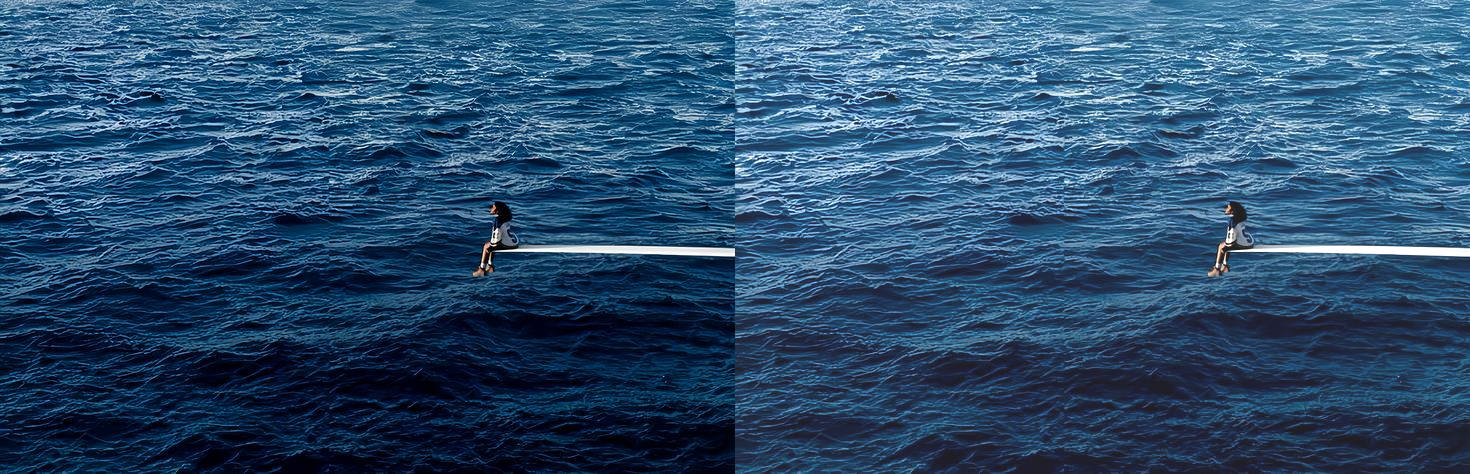

In [6]:
print(' Mengubah tingkat kecerahan citra ')
print('-----------------------------------')
try:
    brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')

#sesuaikan dengan file dan folder di drive Anda
original = cv.imread('/content/drive/MyDrive/PCVK/sza.jpg').astype(np.int16)
brightness_image = np.zeros(original.shape, original.dtype)

#akses per piksel
#np.clip digunakan untuk melakukan truncate piksel (nilai dibatasi antara 0-255)
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)

#cara simple tanpa for loop
#brightness_image = cv.convertScaleAbs(original, beta=brightness)

final_frame = cv.hconcat((original, brightness_image))
cv2_imshow(final_frame)

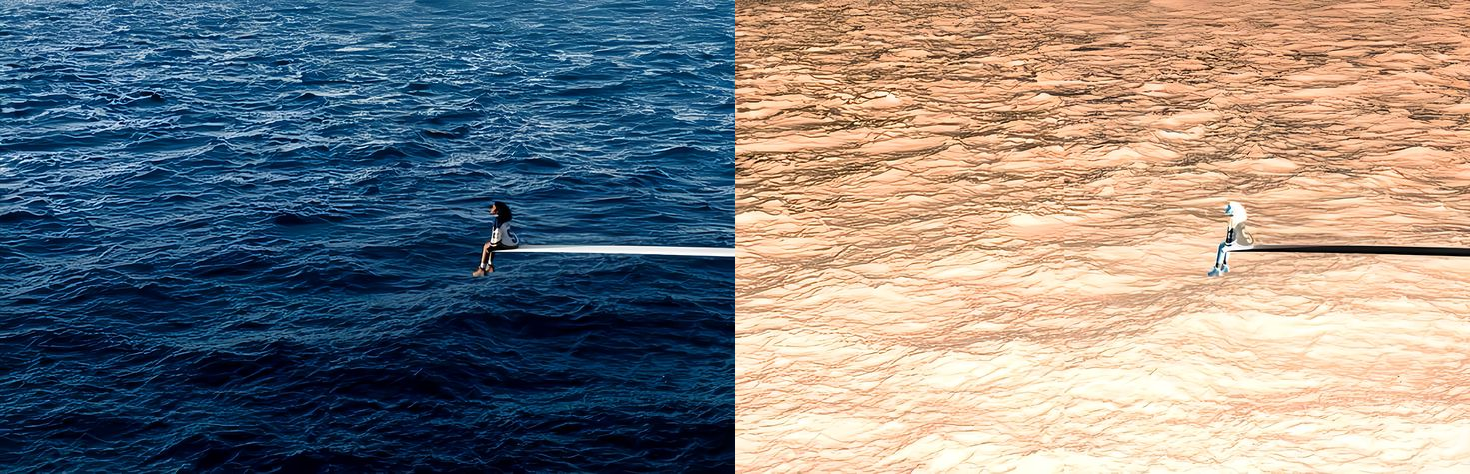

In [7]:
invers_image = 255-original

final_frame = cv.hconcat((original, invers_image))
cv2_imshow(final_frame  )

 Mengubah tingkat kecerahan citra 
-----------------------------------
Masukkan tingkat kecerahan : 10
Masukkan tingkat kontras : 1.5


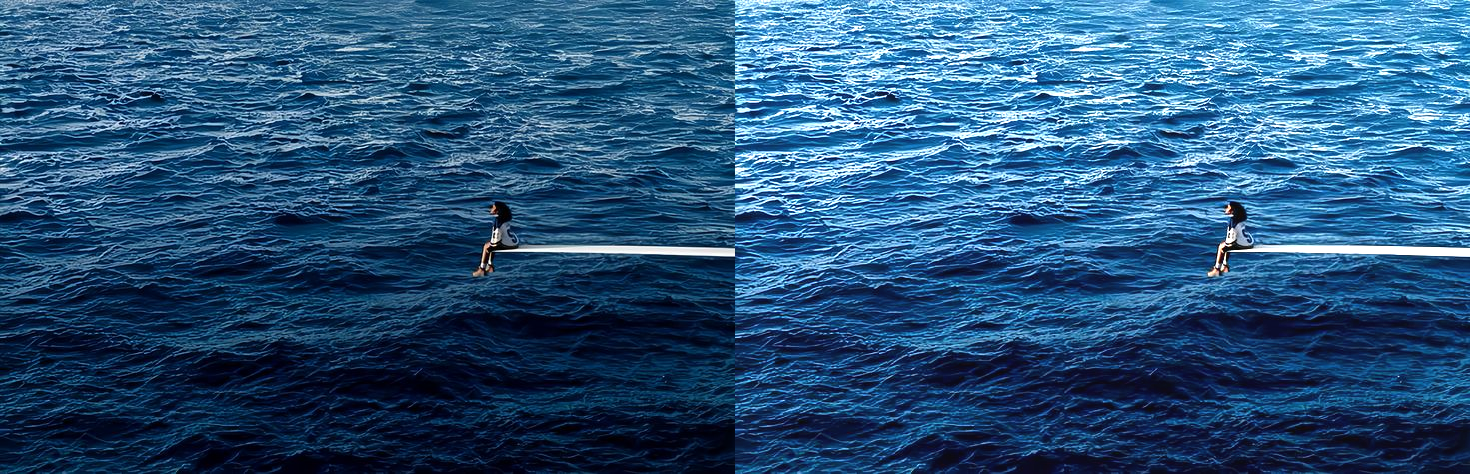

In [12]:
print(' Mengubah tingkat kecerahan citra ')
print('-----------------------------------')
try:
    brightness = int(input('Masukkan tingkat kecerahan : '))
    contrast = float(input('Masukkan tingkat kontras : '))
except ValueError:
    print('Error, not a number')

#sesuaikan dengan file dan folder di drive Anda
contrast_image = cv.convertScaleAbs(original, alpha=contrast, beta=brightness)

final_frame = cv.hconcat((original, contrast_image))
cv2_imshow(final_frame)

 Mengubah tingkat kecerahan citra 
-----------------------------------
Masukkan nilai kecerahan: 50


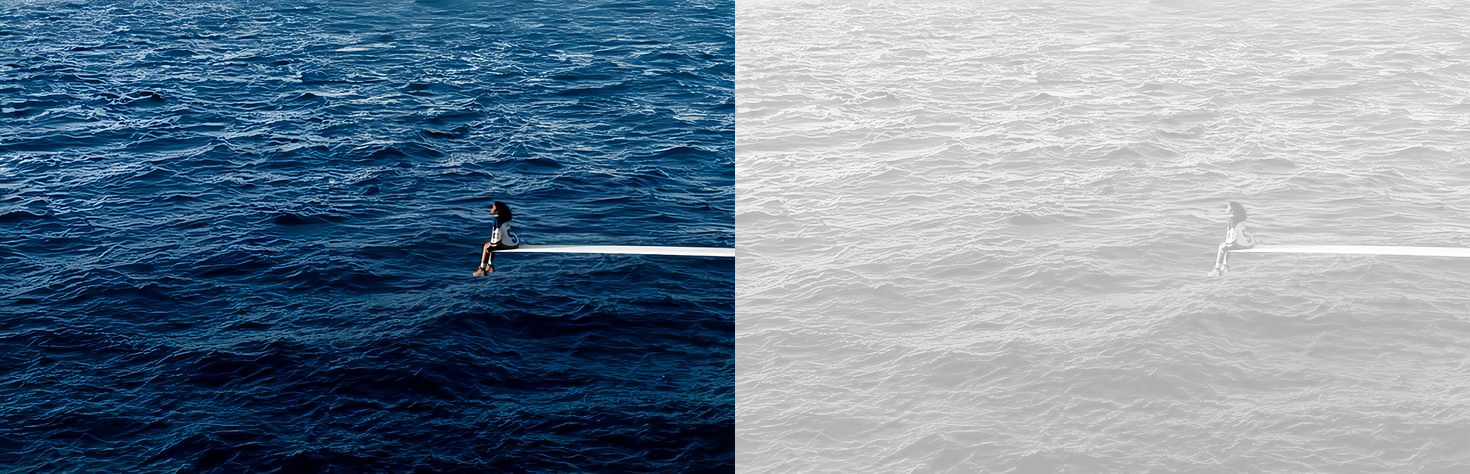

In [15]:
print(' Mengubah tingkat kecerahan citra ')
print('-----------------------------------')
try:
    brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')

gray = cv.cvtColor(original, cv.COLOR_BGR2GRAY)
gray_float = gray.astype(np.float64)

c = 255 / np.log(1 + np.max(gray_float) + brightness)
log_image_float = c * (np.log(1 + gray_float + brightness))

log_image = np.clip(log_image_float, 0, 255).astype(np.uint8)

log_image_bgr = cv.cvtColor(log_image, cv.COLOR_GRAY2BGR)

final_frame = cv.hconcat((original, log_image_bgr))
cv2_imshow(final_frame)